In [33]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Prediction notebook (per-target features & scalers)

- Loads specialized RF models where each target stores:
    {'model': <RF>, 'scaler': <StandardScaler>, 'features': [b? ...]}
- Predicts on new data using each target's own feature subset and scaler.
- Backward compatible: if the models file is old (no dict with 'model','scaler',
  'features'), it falls back to a legacy single scaler file x_scaler_rf_v4.pkl
  and uses all barometer channels as features.

This notebook:
1) Loads the models
2) Loads a synchronized CSV
3) Samples some rows
4) Predicts fx, fy, fz, x, y (or whatever targets exist)
5) Prints error stats
6) Plots predicted vs true for each target
"""

import os
import pickle
from collections.abc import Mapping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Paths
MODEL_DIR   = r"C:\Users\aurir\OneDrive - epfl.ch\Thesis- Biorobotics Lab\models parameters\random forest"
MODEL_FILE  = "specialized_rf_models_v4.pkl"   # new format (per-target)
SCALER_FILE = "x_scaler_rf_v4.pkl"             # legacy single-scaler (fallback)

# Use the test dataset from train_validation_test_data folder
NEW_DATA_DIR  = r"C:\Users\aurir\OneDrive - epfl.ch\Thesis- Biorobotics Lab\train_validation_test_data"
NEW_DATA_FILE = r"validation_data_v4.csv"

# Sampling (set to None to use all test data, or specify a number for sampling)
N_SAMPLES   = None  # Use all test data
RANDOM_SEED = 42

# Preferred display/order for outputs if present
PREFERRED_TARGET_ORDER = ['x', 'y', 'fx', 'fy', 'fz']

# Barometer columns expected in the CSV
BARO_COLS = ['b1', 'b2', 'b3', 'b4', 'b5', 'b6']

# Where to save the prediction CSV (same directory as models by default)
SAVE_PREDICTIONS_IN_MODEL_DIR = True


In [35]:
# =============================================================================
# HELPERS
# =============================================================================

def is_new_models_format(models_obj):
    """
    New format: models is a dict mapping target -> {'model','scaler','features'}.
    Old format: models is a dict mapping target -> sklearn estimator only.
    """
    if not isinstance(models_obj, Mapping):
        return False
    # peek one entry
    k = next(iter(models_obj.keys()))
    v = models_obj[k]
    return isinstance(v, Mapping) and all(key in v for key in ('model', 'scaler', 'features'))


def ordered_targets(keys, preferred_order):
    keys_set = set(keys)
    ordered = [t for t in preferred_order if t in keys_set]
    # append any extra keys in deterministic order
    ordered += [t for t in sorted(keys) if t not in ordered]
    return ordered


def load_models(model_dir, model_file, scaler_file):
    """Load models and (optionally) the legacy global scaler."""
    models_path = os.path.join(model_dir, model_file)
    with open(models_path, 'rb') as f:
        models = pickle.load(f)

    new_format = is_new_models_format(models)

    legacy_scaler = None
    if not new_format:
        # Legacy path: load the single global scaler (all features)
        scaler_path = os.path.join(model_dir, scaler_file)
        with open(scaler_path, 'rb') as f:
            legacy_scaler = pickle.load(f)

    return models, new_format, legacy_scaler


def load_data(data_dir, data_file):
    """Load synchronized CSV and clean column names."""
    data_path = os.path.join(data_dir, data_file)
    df = pd.read_csv(data_path)
    df.columns = df.columns.str.strip()
    return df


def select_samples(df, n_samples, seed=None):
    """
    Randomly select up to n_samples rows and return sub-DataFrame + indices.
    If n_samples is None, use all data.
    """
    if seed is not None:
        np.random.seed(seed)

    # If n_samples is None, use all data
    if n_samples is None:
        print(f"Using all {len(df)} samples from the dataset.")
        indices = np.arange(len(df))
        return df.copy(), indices

    if n_samples > len(df):
        print(f"⚠️  Dataset has only {len(df)} samples, using all of them.")
        n_samples = len(df)

    indices = np.random.choice(len(df), size=n_samples, replace=False)
    df_sample = df.iloc[indices].copy()
    print(f"Selected {n_samples} random samples.")
    return df_sample, indices


def predict_all_targets(df_sample, models, new_format, legacy_scaler,
                        baro_cols, preferred_order):
    """
    Compute predictions for all targets in 'models' on df_sample.

    Returns:
        results: DataFrame with baro cols + *_pred + optional *_true + *_error
        output_targets: ordered list of targets
    """
    # Determine target order
    output_targets = ordered_targets(list(models.keys()), preferred_order)
    print(f"Targets: {output_targets}\n")

    # Check barometer columns
    for b in baro_cols:
        if b not in df_sample.columns:
            raise ValueError(f"Missing barometer column '{b}' in input CSV.")

    # Base result frame: barometer channels
    results = pd.DataFrame({
        **{b: df_sample[b].values for b in baro_cols}
    })

    # Make predictions per target
    predictions = {}

    for target in output_targets:
        if new_format:
            # New: each target carries (model, scaler, features)
            entry  = models[target]
            model  = entry['model']
            scaler = entry['scaler']
            feats  = entry['features']

            # Sanity check on features presence
            for c in feats:
                if c not in df_sample.columns:
                    raise ValueError(
                        f"Target '{target}' expects feature '{c}' not found in input CSV."
                    )

            X_new    = df_sample[feats].values
            X_scaled = scaler.transform(X_new)
            pred     = model.predict(X_scaled)

        else:
            # Legacy: single global scaler, all barometers
            feats  = baro_cols
            model  = models[target]
            X_new  = df_sample[feats].values
            X_scaled = legacy_scaler.transform(X_new)
            pred   = model.predict(X_scaled)

        predictions[target] = pred
        results[f'{target}_pred'] = pred

    # Add ground truth + error if columns exist in df_sample
    for target in output_targets:
        if target in df_sample.columns:
            true_vals = df_sample[target].values
            results[f'{target}_true'] = true_vals
            results[f'{target}_error'] = true_vals - results[f'{target}_pred'].values

    return results, output_targets


def print_error_table(results, output_targets, show_full_table=False):
    """Pretty-print predictions vs true (if available) and basic error stats."""
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.float_format', '{:.4f}'.format)

    have_truth = any(f'{t}_true' in results.columns for t in output_targets)

    if have_truth:
        if show_full_table:
            print("\n📊 PREDICTIONS vs ACTUAL VALUES:\n")
            display_cols = []
            # If there's an index column from selection, use it; otherwise skip
            if 'Sample_Index' in results.columns:
                display_cols.append('Sample_Index')
            display_cols.extend(['b1', 'b2', 'b3', 'b4', 'b5', 'b6'])
            for t in output_targets:
                display_cols.extend([f'{t}_pred', f'{t}_true', f'{t}_error'])

            # Use intersection in case some columns are missing
            display_cols = [c for c in display_cols if c in results.columns]
            print(results[display_cols].to_string(index=False))

        # Error stats
        print("\n" + "="*70)
        print("ERROR STATISTICS")
        print("="*70)
        for t in output_targets:
            err_col = f'{t}_error'
            if err_col in results.columns:
                e = results[err_col].values
                mae  = np.abs(e).mean()
                rmse = np.sqrt((e**2).mean())
                unit = "mm" if t in ['x', 'y'] else "N"
                print(f"\n{t.upper()}:")
                print(f"  MAE:  {mae:.4f} {unit}")
                print(f"  RMSE: {rmse:.4f} {unit}")
    else:
        print("\n📊 PREDICTIONS (no ground truth columns found in CSV):\n")
        display_cols = []
        if 'Sample_Index' in results.columns:
            display_cols.append('Sample_Index')
        display_cols.extend(['b1', 'b2', 'b3', 'b4', 'b5', 'b6'])
        display_cols.extend([f'{t}_pred' for t in output_targets
                             if f'{t}_pred' in results.columns])
        display_cols = [c for c in display_cols if c in results.columns]
        print(results[display_cols].to_string(index=False))


def save_predictions(results, new_data_file, model_dir, in_model_dir=True):
    """Save prediction DataFrame to CSV."""
    base_dir = model_dir if in_model_dir else os.path.dirname(new_data_file)
    output_filename = new_data_file.replace('\\', '_').replace('/', '_') \
                                   .replace('.csv', '_predictions.csv')
    output_path = os.path.join(base_dir, output_filename)
    results.to_csv(output_path, index=False)
    print(f"\n✓ Saved predictions to: {output_path}")
    return output_path


def plot_true_vs_pred(results, target, figsize=(5, 5)):
    """
    Scatter plot: true vs predicted for a single target.
    Uses only rows where both *_true and *_pred exist.
    """
    pred_col = f'{target}_pred'
    true_col = f'{target}_true'
    if pred_col not in results.columns or true_col not in results.columns:
        print(f"⚠️  Cannot plot {target}: missing '{pred_col}' or '{true_col}'.")
        return

    y_true = results[true_col].values
    y_pred = results[pred_col].values

    plt.figure(figsize=figsize)
    plt.scatter(y_true, y_pred, alpha=0.5)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    plt.xlabel(f"True {target}")
    plt.ylabel(f"Predicted {target}")
    plt.title(f"True vs Predicted – {target}")
    plt.grid(True)
    plt.show()


In [36]:
# =============================================================================
# RUN PREDICTION
# =============================================================================

# 1) Load models
models, new_format, legacy_scaler = load_models(MODEL_DIR, MODEL_FILE, SCALER_FILE)
print(f"New models format: {new_format}")

# 2) Load data
df_new = load_data(NEW_DATA_DIR, NEW_DATA_FILE)
print(f"Loaded data shape: {df_new.shape}")

# 3) Select samples (or use all if N_SAMPLES is None)
df_sample, indices = select_samples(df_new, N_SAMPLES, seed=RANDOM_SEED)

# Store sample indices in results for reference
results, OUTPUT_TARGETS = predict_all_targets(
    df_sample,
    models=models,
    new_format=new_format,
    legacy_scaler=legacy_scaler,
    baro_cols=BARO_COLS,
    preferred_order=PREFERRED_TARGET_ORDER,
)

# Add sample indices as a column (optional but useful)
results.insert(0, 'Sample_Index', indices)

# 4) Print error stats (set show_full_table=True to see all predictions)
print_error_table(results, OUTPUT_TARGETS, show_full_table=False)

# 5) Save predictions to CSV
save_predictions(
    results,
    NEW_DATA_FILE,
    MODEL_DIR,
    in_model_dir=SAVE_PREDICTIONS_IN_MODEL_DIR
)


New models format: False
Loaded data shape: (8260, 15)
Using all 8260 samples from the dataset.
Targets: ['x', 'y', 'fx', 'fy', 'fz']


ERROR STATISTICS

X:
  MAE:  2.2017 mm
  RMSE: 3.1704 mm

Y:
  MAE:  1.4914 mm
  RMSE: 1.9349 mm

FX:
  MAE:  0.4317 N
  RMSE: 0.5693 N

FY:
  MAE:  0.4387 N
  RMSE: 0.5818 N

FZ:
  MAE:  0.5827 N
  RMSE: 0.7988 N

✓ Saved predictions to: C:\Users\aurir\OneDrive - epfl.ch\Thesis- Biorobotics Lab\models parameters\random forest\validation_data_v4_predictions.csv


'C:\\Users\\aurir\\OneDrive - epfl.ch\\Thesis- Biorobotics Lab\\models parameters\\random forest\\validation_data_v4_predictions.csv'

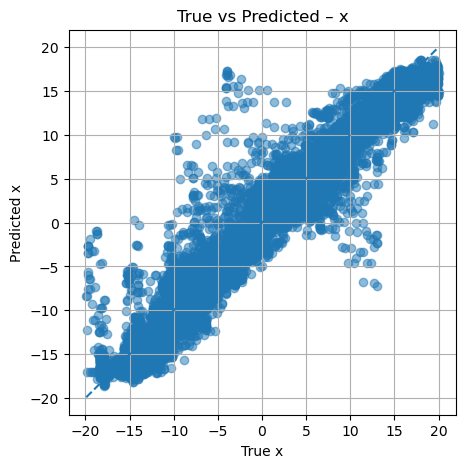

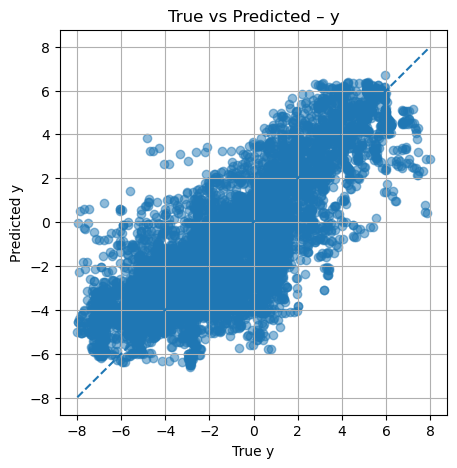

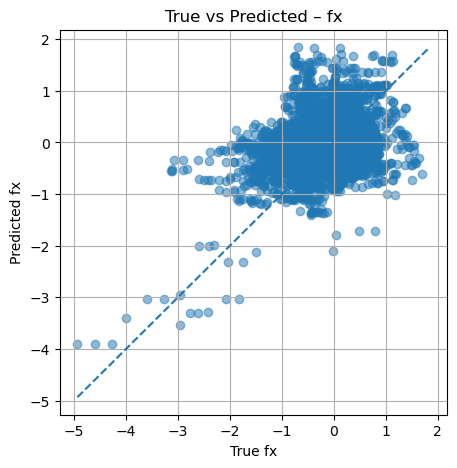

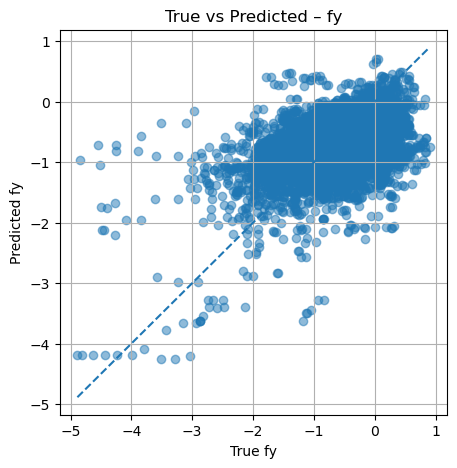

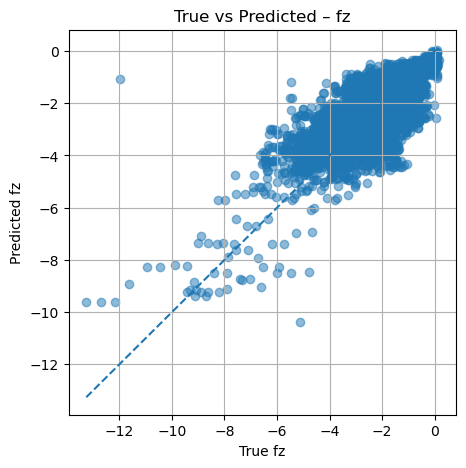

In [37]:
# =============================================================================
# PLOTS: TRUE vs PRED
# =============================================================================

# Choose which targets to plot; default = all the ones in OUTPUT_TARGETS
target_list = OUTPUT_TARGETS

for t in target_list:
    plot_true_vs_pred(results, t)


Using 't' as time axis.
Chunk size: 5000 samples (rows 0 to 4999)
Targets: ['x', 'y', 'fx', 'fy', 'fz']



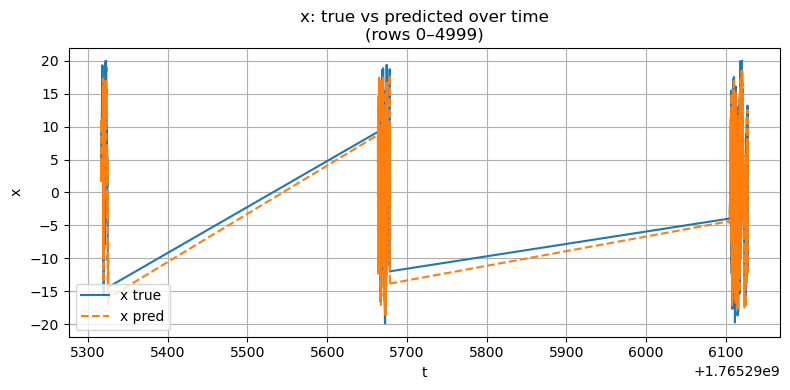

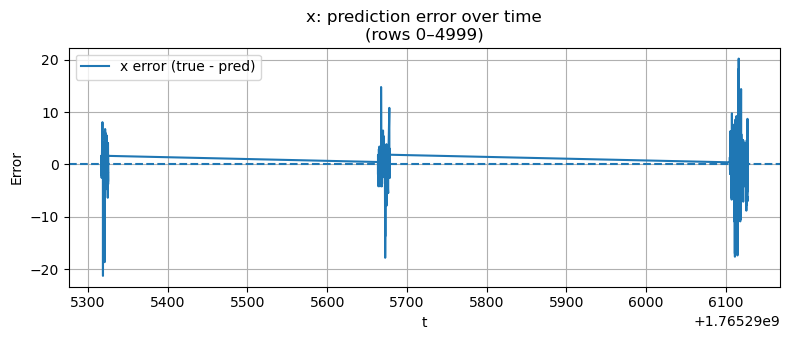

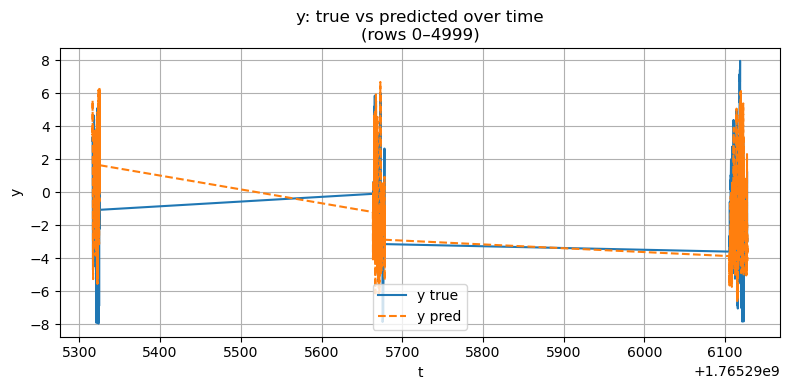

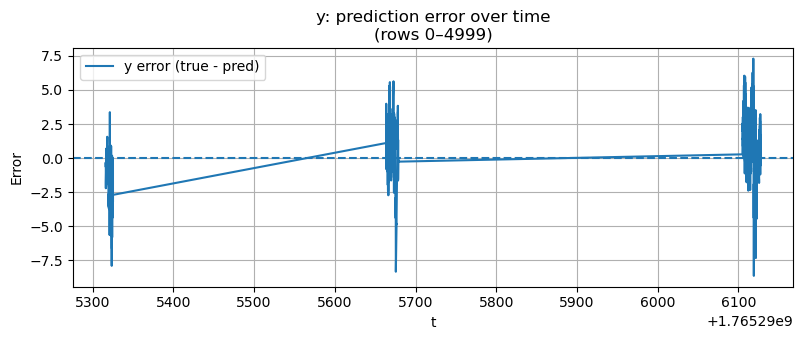

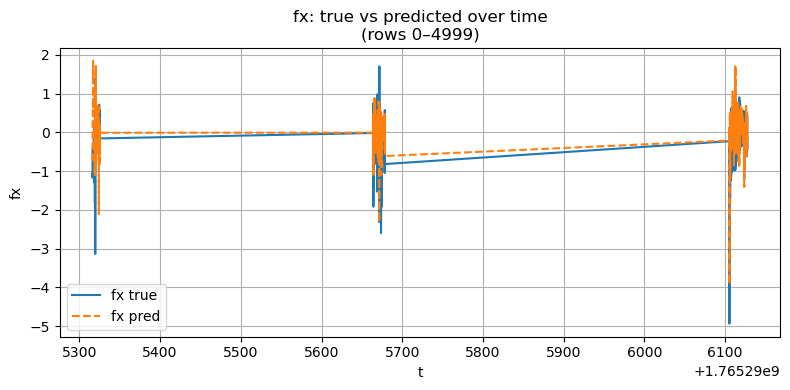

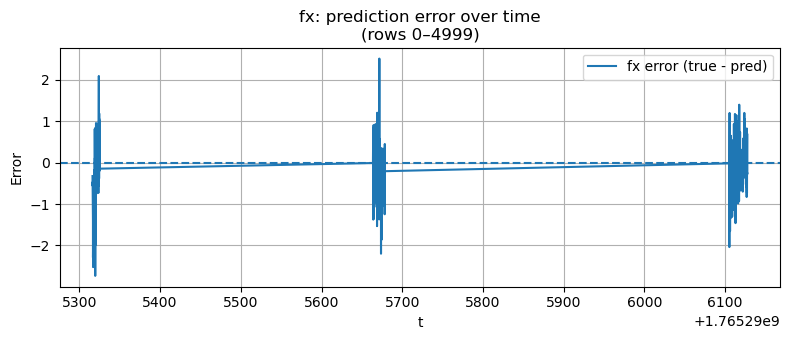

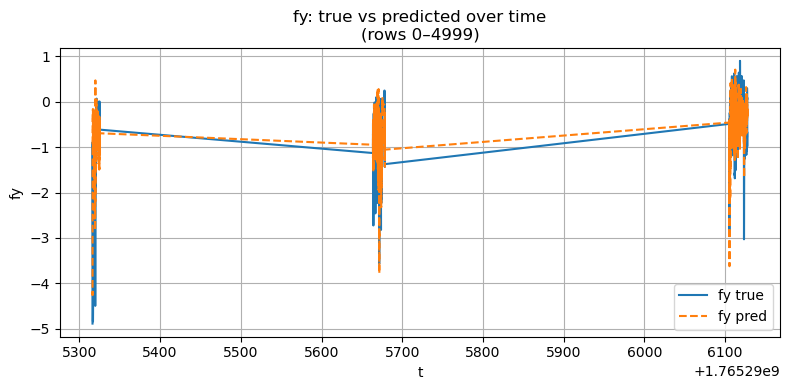

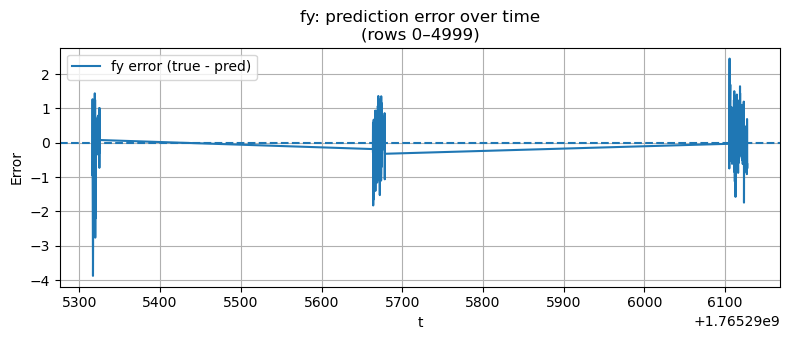

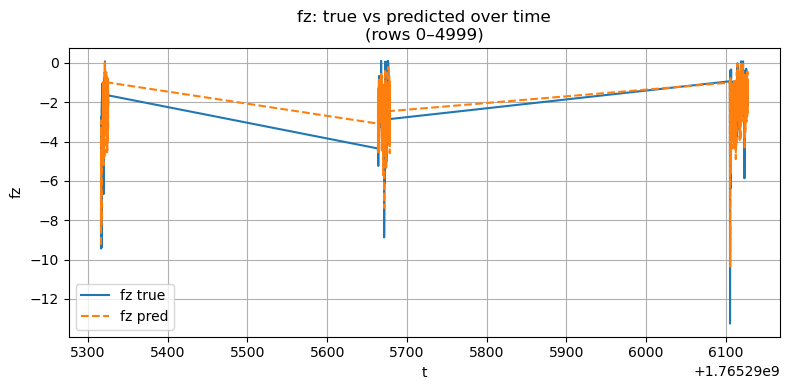

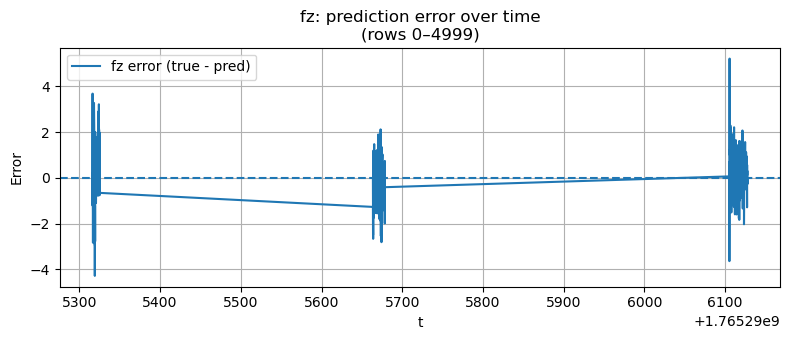

: 

In [ ]:
# =============================================================================
# TIME-SERIES CHUNK: TRUE & PRED vs TIME + ERROR
# =============================================================================

# --- Choose which column to use as "time" ---
# We try a few common names and pick the first that exists
TIME_COL = None
for cand in ['t', 'time', 'time_s', 'time_sec']:
    if cand in df_new.columns:
        TIME_COL = cand
        break

if TIME_COL is None:
    print("⚠️ No explicit time column found; will use row index as x-axis.")
else:
    print(f"Using '{TIME_COL}' as time axis.")

# --- Choose a contiguous chunk of the dataset by index ---
# Adjust these indices depending on how long your test is
start_idx = 0        # inclusive
end_idx   = 5000      # exclusive

if end_idx > len(df_new):
    end_idx = len(df_new)
    print(f"⚠️ end_idx truncated to dataset length = {end_idx}")

df_chunk = df_new.iloc[start_idx:end_idx].copy()
print(f"Chunk size: {len(df_chunk)} samples "
      f"(rows {start_idx} to {end_idx - 1})")

# --- Run predictions on this chunk ---
results_ts, targets_ts = predict_all_targets(
    df_chunk,
    models=models,
    new_format=new_format,
    legacy_scaler=legacy_scaler,
    baro_cols=BARO_COLS,
    preferred_order=PREFERRED_TARGET_ORDER,
)

# Build time axis
if TIME_COL is not None:
    time_axis = df_chunk[TIME_COL].values
else:
    time_axis = np.arange(len(df_chunk))

# --- Plot time series for each target ---
# You can restrict this list if you only want some of them
targets_to_plot = targets_ts

for t in targets_to_plot:
    true_col  = f"{t}_true"
    pred_col  = f"{t}_pred"
    error_col = f"{t}_error"

    if true_col not in results_ts.columns or pred_col not in results_ts.columns:
        print(f"⚠️ Skipping {t}: missing {true_col} or {pred_col}")
        continue

    # -----------------------------
    # 1) TRUE vs PRED vs TIME
    # -----------------------------
    plt.figure(figsize=(8, 4))
    plt.plot(time_axis, results_ts[true_col].values, label=f"{t} true")
    plt.plot(time_axis, results_ts[pred_col].values, label=f"{t} pred", linestyle="--")

    plt.xlabel("Time" if TIME_COL is None else TIME_COL)
    plt.ylabel(t)
    plt.title(f"{t}: true vs predicted over time\n(rows {start_idx}–{end_idx - 1})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 2) ERROR vs TIME
    # -----------------------------
    if error_col in results_ts.columns:
        err = results_ts[error_col].values

        plt.figure(figsize=(8, 3.5))
        plt.plot(time_axis, err, label=f"{t} error (true - pred)")
        plt.axhline(0, linestyle="--")
        plt.xlabel("Time" if TIME_COL is None else TIME_COL)
        plt.ylabel("Error")
        plt.title(f"{t}: prediction error over time\n(rows {start_idx}–{end_idx - 1})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ No error column {error_col} for target {t}, skipping error plot.")
